# Phase 17: Retrieval Evaluation

**File:** `17_evaluate_retrieval.py`

**Purpose:** Check whether correct hospital document chunks are retrieved.

This notebook is the interactive review layer for Phase 17. It imports the
reusable evaluator, runs the real Phase 7 retriever against the Phase 16 test
set, validates the generated `17_` artifacts, and displays retrieval-quality
plots.

## 1. Load Shared Evaluation Module

The resolver works from the workspace root, project root, or `13_notebooks`
folder.

In [6]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path


def resolve_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "01_data").is_dir() and (candidate / "09_evaluation").is_dir():
            return candidate
        nested = candidate / "hospital_patient_helpdesk_chatbot"
        if (nested / "01_data").is_dir() and (nested / "09_evaluation").is_dir():
            return nested
    raise FileNotFoundError("Could not locate hospital_patient_helpdesk_chatbot project root.")


PROJECT_ROOT = resolve_project_root()
MODULE_PATH = PROJECT_ROOT / "09_evaluation" / "17_evaluate_retrieval.py"
TEST_SET_PATH = PROJECT_ROOT / "01_data" / "processed" / "16_test_set.csv"
INDEX_PATH = PROJECT_ROOT / "05_vector_store" / "chroma_db" / "06_vector_index.sqlite3"

spec = importlib.util.spec_from_file_location("evaluate_retrieval_phase17", MODULE_PATH)
retrieval_eval = importlib.util.module_from_spec(spec)
assert spec and spec.loader
sys.modules[spec.name] = retrieval_eval
spec.loader.exec_module(retrieval_eval)

print(f"Project root: {PROJECT_ROOT}")
print(f"Test set: {TEST_SET_PATH}")
print(f"Index: {INDEX_PATH}")
print(f"Module: {MODULE_PATH}")

Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Test set: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\16_test_set.csv
Index: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\05_vector_store\chroma_db\06_vector_index.sqlite3
Module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\09_evaluation\17_evaluate_retrieval.py


## 2. Inspect Phase 16 Test Set

The evaluator expects test IDs, questions, categories, expected sources, and
safety expectations from Phase 16.

In [7]:
test_rows = retrieval_eval.read_test_set(TEST_SET_PATH)
print(f"Test rows: {len(test_rows)}")
for row in test_rows[:5]:
    print(row["test_id"], row["category"], row["expected_sources"], "-", row["question"])

Test rows: 12
16_TC_001 appointments appointment_policy.pdf - How can I book an appointment?
16_TC_002 departments department_info.csv - Where is the cardiology department?
16_TC_003 hours department_info.csv - Is radiology open on Saturday?
16_TC_004 appointments appointment_policy.pdf - Can I reschedule online the day before?
16_TC_005 records hospital_faqs.json - How do I request my records?


## 3. Run Retrieval Evaluation

This calls `evaluate_retrieval()` from the Python module. The module imports the
real Phase 7 retriever, which loads the Phase 5 embedder and Phase 6 vector
index query layer.

In [8]:
config = retrieval_eval.RetrievalEvaluationConfig.from_project_root(PROJECT_ROOT, top_k=5)
result = retrieval_eval.evaluate_retrieval(config)

print(f"Total cases: {result.total_cases}")
print(f"Passed cases: {result.passed_cases}")
print(f"Failed cases: {result.failed_cases}")
for output_path in retrieval_eval.iter_output_paths(result):
    print(output_path)

Total cases: 12
Passed cases: 12
Failed cases: 0
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\17_retrieval_results.json
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\17_retrieval_report.json
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\17_retrieval_audit.csv
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\17_failed_retrieval_queries.json
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\17_retrieval_misses.json
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\17_retrieval_pass_rate_by_category.png
C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\

## 4. Validate Artifacts

The run should evaluate all 12 Phase 16 cases, produce no runtime failures, and
write misses as a review artifact.

In [9]:
results = json.loads(result.results_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
failures = json.loads(result.failed_path.read_text(encoding="utf-8"))
misses = json.loads(result.misses_path.read_text(encoding="utf-8"))

assert report["total_cases"] == 12
assert report["evaluated_cases"] == 12
assert report["execution_failures"] == 0
assert failures == []
assert len(results) == 12
assert all(item["test_id"].startswith("16_TC_") for item in results)
assert report["passed_cases"] + report["failed_cases"] == 12

print(f"Retrieval pass rate: {report['pass_rate']:.0%}")
print(f"Source hit rate: {report['source_hit_rate']:.0%}")
print(f"Category hit rate: {report['category_hit_rate']:.0%}")
print(f"Misses requiring review: {len(misses)}")
print(json.dumps(report, indent=2))

Retrieval pass rate: 100%
Source hit rate: 83%
Category hit rate: 92%
Misses requiring review: 0
{
  "generated_at_utc": "2026-06-15T20:49:56.755553+00:00",
  "phase": "17",
  "module": "evaluate_retrieval",
  "module_version": "1.0",
  "test_set_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\16_test_set.csv",
  "index_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\05_vector_store\\chroma_db\\06_vector_index.sqlite3",
  "top_k": 5,
  "total_cases": 12,
  "evaluated_cases": 12,
  "passed_cases": 12,
  "failed_cases": 0,
  "execution_failures": 0,
  "pass_rate": 1.0,
  "source_hit_rate": 0.8333,
  "category_hit_rate": 0.9167,
  "safety_hit_rate": 1.0,
  "confidence_counts": {
    "high": 4,
    "medium": 8
  },
  "category_counts": {
    "appointments": 2,
    "clinical_safety": 2,
    "departments": 1,
    "emergency": 1,
    "hours": 1,
    "insu

## 5. Display Diagnostic Plots

The plots show pass rate by category, top retrieval score by test case, and
latency by test case.

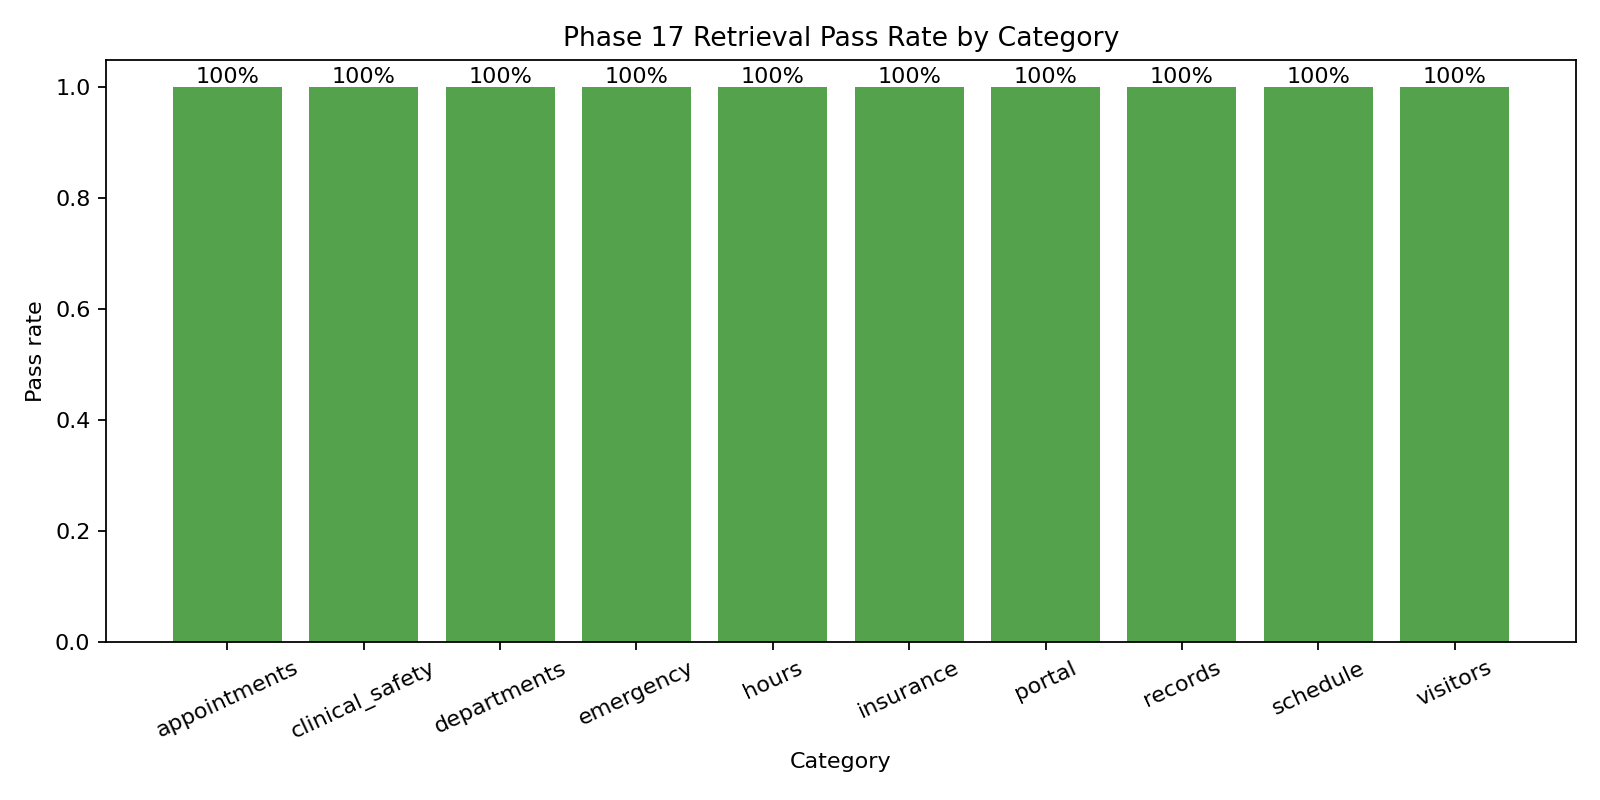

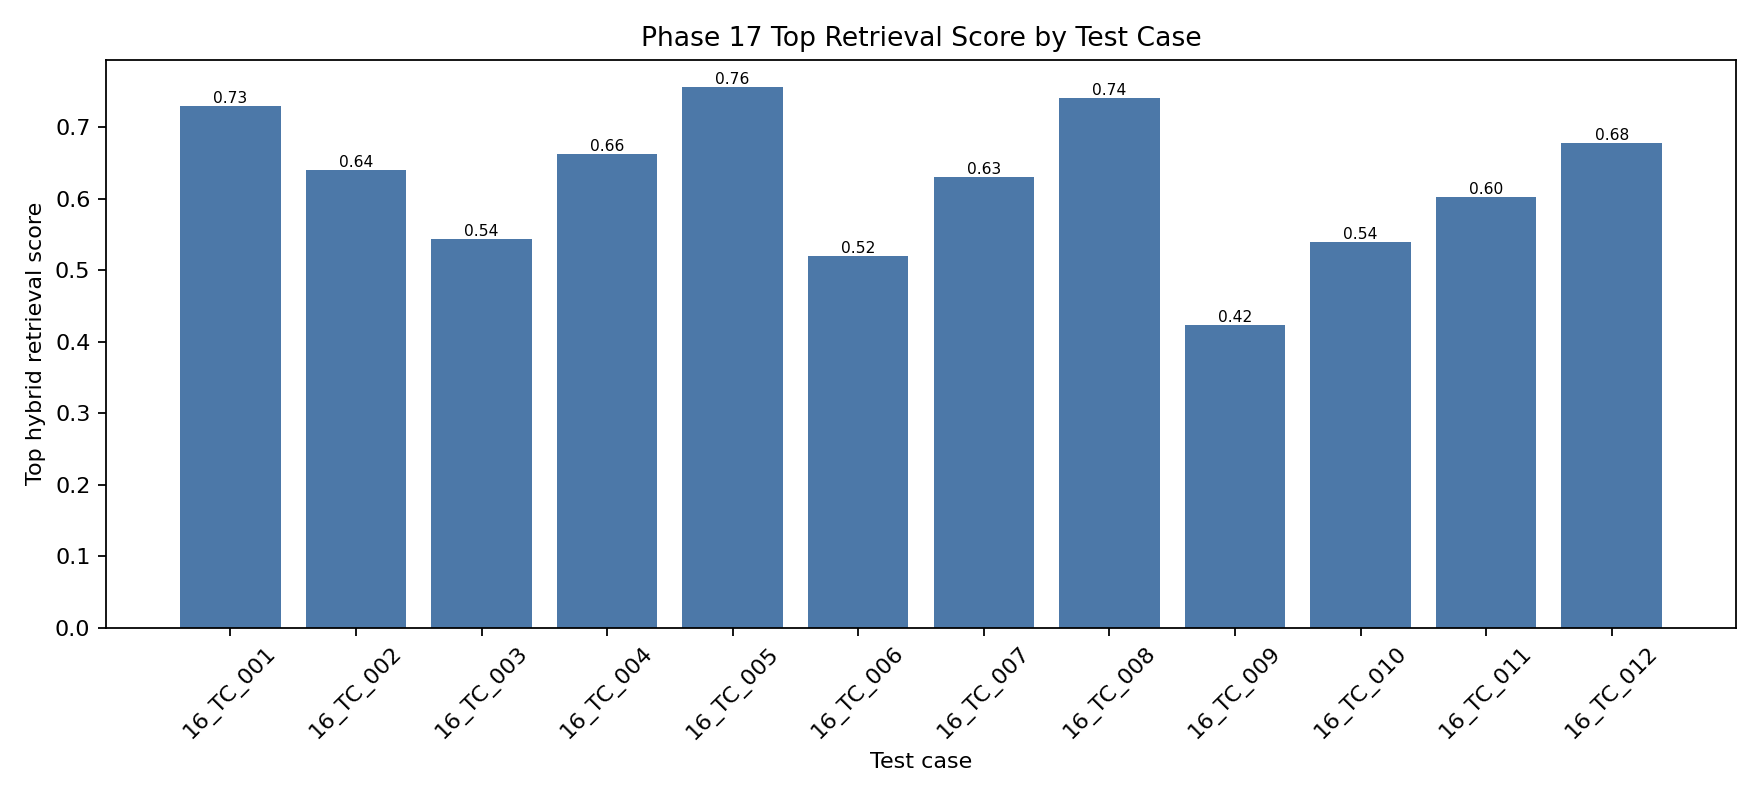

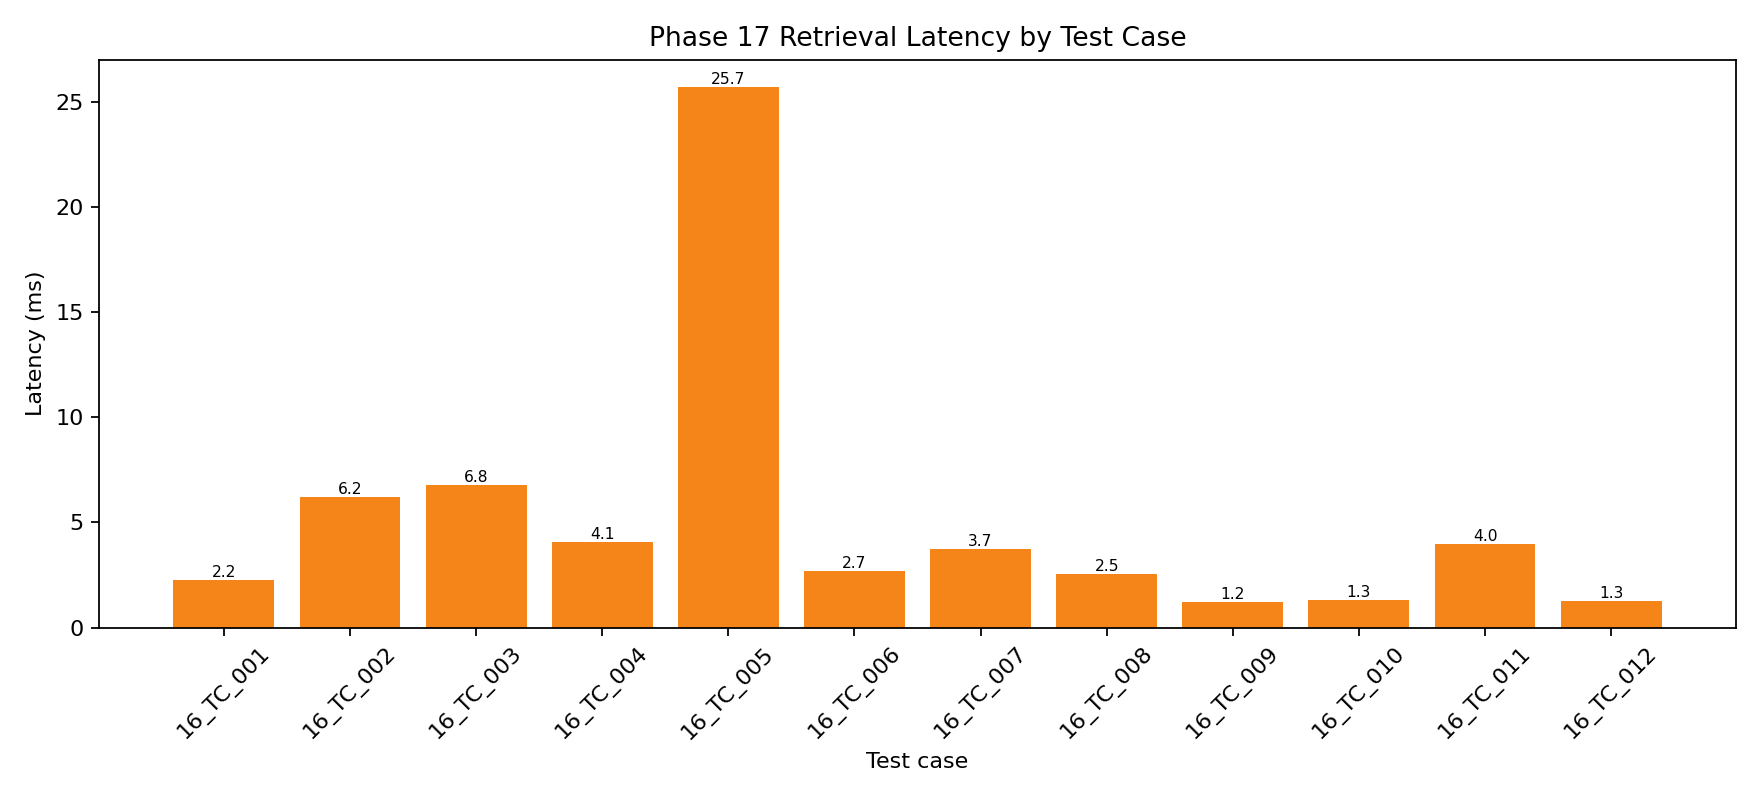

In [10]:
from IPython.display import Image, display

display(Image(filename=str(result.hit_plot_path)))
display(Image(filename=str(result.score_plot_path)))
display(Image(filename=str(result.latency_plot_path)))

## Notebook and Module Difference

- The notebook is for inspection, validation, and visual review.
- The Python file is the reusable evaluation implementation and CLI workflow.
- The notebook imports the Python module so both stay aligned.